In [1]:
import pandas as pd
import psycopg2

from jupyter_dash import JupyterDash

from dash import html
from dash import dcc
from dash import dash_table

import plotly.express as px

In [2]:
conn = psycopg2.connect(
    host="localhost",
    database="nutrient_db2",
    user="postgres",
    password="Codio590"
)

print(
    "PostgreSQL Connected Successfully"
)

PostgreSQL Connected Successfully


In [3]:
query = '''

SELECT

f."Food category code",

c."Category description",

f."Descriptor",

f."Last modified"

FROM fdes f

LEFT JOIN ctgnme c

ON

f."Food category code"
=
c."Food category code"

LIMIT 500

'''

df = pd.read_sql(
    query,
    conn
)

df.head()

/tmp/ipykernel_76914/146269132.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,Food category code,Category description,Descriptor,Last modified
0,1,Dairy and Egg Products,"Butter, salted",01/04/2010
1,1,Dairy and Egg Products,"Butter, whipped, with salt",02/13/2019
2,1,Dairy and Egg Products,"Butter oil, anhydrous",12/23/2013
3,1,Dairy and Egg Products,"Cheese, blue",11/30/2006
4,1,Dairy and Egg Products,"Cheese, brick",12/23/2013


In [4]:
category_counts = (

    df.groupby(
        "Category description"
    )

    .size()

    .reset_index(
        name="Food Count"
    )

)

category_counts

,Category description,Food Count
0,Baby Foods,170
1,Dairy and Egg Products,230
2,Fats and Oils,38
3,Spices and Herbs,62


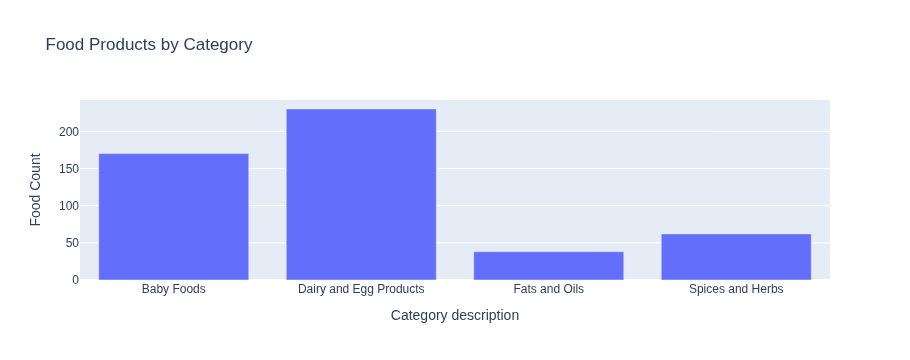

In [5]:
fig = px.bar(

    category_counts,

    x="Category description",

    y="Food Count",

    title=
    "Food Products by Category"

)

fig.show()

In [6]:
categories = sorted(
    df["Category description"]
    .dropna()
    .unique()
)

print(
    "Categories Loaded:",
    len(categories)
)

Categories Loaded: 4


In [7]:
app = JupyterDash(__name__)

app.layout = html.Div([

    html.H1(
        "USDA Food Products Dashboard"
    ),

    html.H3(
        "Food Category Analysis"
    ),

    dcc.Dropdown(

        id="category-filter",

        options=[
            {
                "label": c,
                "value": c
            }
            for c in categories
        ],

        placeholder=
        "Select Food Category"

    ),

    dcc.Graph(
        id="food-chart",
        figure=fig
    ),

    dash_table.DataTable(

        id="food-table",

        data=df.to_dict(
            "records"
        ),

        columns=[
            {
                "name": i,
                "id": i
            }
            for i in df.columns
        ],

        page_size=10,

        style_table={
            "overflowX":"auto"
        }

    )

])

/home/ubuntu/.local/lib/python3.13/site-packages/dash/dash.py:642: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



In [8]:
from dash.dependencies import Input, Output

@app.callback(

    Output(
        "food-table",
        "data"
    ),

    Input(
        "category-filter",
        "value"
    )

)

def update_table(selected_category):

    if selected_category is None:

        return df.to_dict(
            "records"
        )

    filtered_df = df[
        df[
            "Category description"
        ]
        ==
        selected_category
    ]

    return filtered_df.to_dict(
        "records"
    )

In [10]:
app.run(
    debug=False
)